# Elbow Method and Silhouette Score

## To determine a suitable number of clusters (k) for customer segmentation 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
import pandas as pd


In [6]:
import os

print(os.getcwd())

c:\Users\techn\OneDrive\customer-segmentation\customer-segmentation\notebooks


In [ ]:
print(os.listdir())


In [7]:
print(os.listdir("../"))

['.git', '.gitignore', '.ipynb_checkpoints', 'data', 'docs', 'models', 'notebooks', 'README.md', 'reports', 'requirements.txt', 'src', 'venv']


In [8]:
print(os.listdir("../data"))

['processed', 'raw', 'scaled_customer_data.csv']


In [9]:
X_scaled = pd.read_csv("../data/scaled_customer_data.csv")

In [10]:
X_scaled.head()

,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


In [11]:
X_scaled.shape

(200, 2)

In [12]:
X_scaled.columns

Index(['Annual Income (k$)', 'Spending Score (1-100)'], dtype='str')

In [13]:
X_scaled = X_scaled.values

In [14]:
X_scaled.shape

(200, 2)

In [15]:
from sklearn.cluster import KMeans


In [16]:
k_values = range(2, 11)

In [17]:
inertias = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

In [18]:
for k, inertia in zip(k_values, inertias):
    print(f"K = {k}: Inertia = {inertia:.2f}")

    

K = 2: Inertia = 269.69
K = 3: Inertia = 157.70
K = 4: Inertia = 108.92
K = 5: Inertia = 65.57
K = 6: Inertia = 55.06
K = 7: Inertia = 44.86
K = 8: Inertia = 37.23
K = 9: Inertia = 32.39
K = 10: Inertia = 29.98


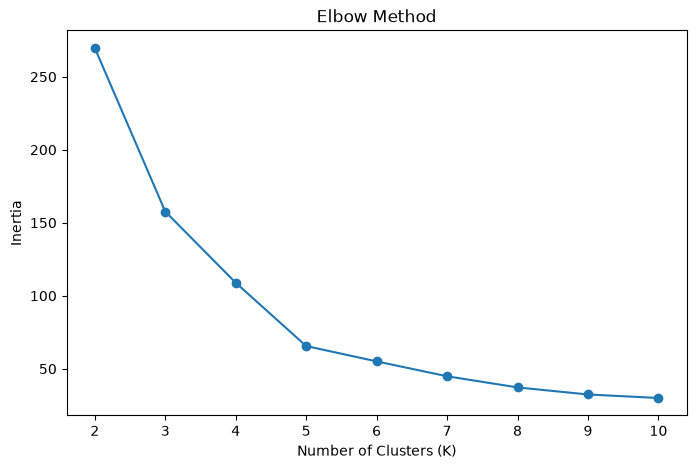

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [20]:
from sklearn.metrics import silhouette_score

In [21]:
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    

In [22]:
for k, score in zip(k_values, silhouette_scores):
    print(f"K = {k}: Silhouette Score = {score:.4f}")
    


K = 2: Silhouette Score = 0.3213
K = 3: Silhouette Score = 0.4666
K = 4: Silhouette Score = 0.4939
K = 5: Silhouette Score = 0.5547
K = 6: Silhouette Score = 0.5399
K = 7: Silhouette Score = 0.5281
K = 8: Silhouette Score = 0.4552
K = 9: Silhouette Score = 0.4571
K = 10: Silhouette Score = 0.4432


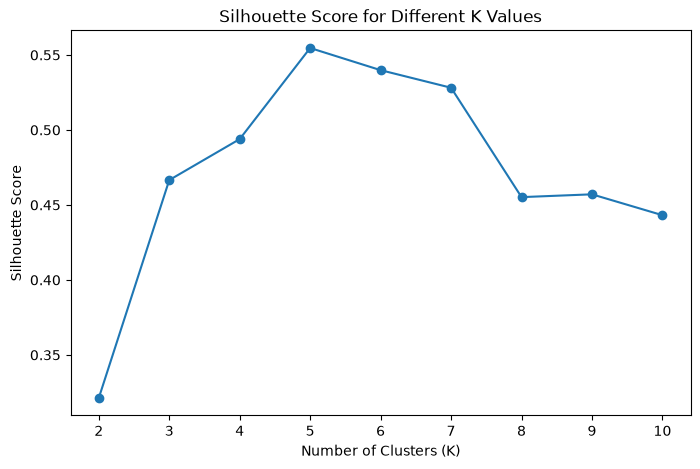

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")
plt.show()

## Interpretation

The Elbow Method shows a noticeable reduction in inertia up to around K = 5, after which the improvement becomes smaller.

The Silhouette Score reaches its highest value at K = 5 among the tested values (K = 2 to K = 10).

Since both the Elbow Method and Silhouette Score indicate K = 5, we select 5 as the number of clusters for the K-Means clustering stage.